## PyTorch Fashion MNIST DataSet

- 기본 MLP(다층 퍼섭트론)으로 분류
- 로직스틱 회귀

### 1. 라이브러리 로드

In [53]:
# 라이브러리 로드
import torch
import torchvision  # 컴퓨터비젼 모듈
import torchvision.transforms as transforms # 데이터 변환

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [54]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))  # sm_120 의미 12.0 버전

2.12.0+cu130
13.0
NVIDIA GeForce RTX 5060
(12, 0)


### 2. 데이터전처리

In [55]:
# 데이터전처리(Transform) 정의
transform = transforms.Compose([
    # 이미지를 Tensor 형태로 변환
    transforms.ToTensor(),
    # 정규화, 0~1 범위값을 -1~1 범위로 변경
    transforms.Normalize((0.5,), (0.5,))
])

### 3. FashionMNIST 데이터셋 다운로드(학습데이터/테스트데이터)

In [56]:
# 학습데이터
train_dataset = torchvision.datasets.FashionMNIST(
    # 데이터 저장경로
    root='./data',
    # 학습용 데이터셋 사용여부
    train=True,
    # 로컬에 데이터가 없으면 자동 다운로드
    download=True,
    # transform적용
    transform=transform
)

In [57]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

### 4. 데이터셋을 학습 데이터로더로 변경

In [58]:
# 학습 데이터로더 생성
train_loader = torch.utils.data.DataLoader(
    # 사용할 데이터셋 지정
    train_dataset,
    # 한번에 가져올 데이터개수 지정
    batch_size=64,
    # 데이터를 매 epoch 마다 데이터 섞음
    shuffle=True
)

In [59]:
train_loader

### 5. 테스트 데이터셋 다운로드

In [60]:
test_dataset = torchvision.datasets.FashionMNIST(
    # 데이터 저장경로
    root='./data',
    # 테스트 데이터
    train=False,
    # 로컬에 데이터가 없으면 자동 다운로드
    download=True,
    # transform적용
    transform=transform
)

In [61]:
test_dataset

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

### 6. 테스트 데이터로드 생성

In [62]:
test_loader = torch.utils.data.DataLoader(
    # 사용할 데이터셋 지정
    test_dataset,
    # 한번에 가져올 데이터개수 지정
    batch_size=64,
    # 테스트 데이터는 섞을 필요없음
    shuffle=False
)

### 7. PyTorch GPU 사용가능 여부확인
- Compute Unified Device Architecture : NVIDIA가 제공하는 GPU 병렬컴퓨팅 플랫폼

In [63]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
f'사용 장치 : {device}'

'사용 장치 : cuda'

### 8. FashionMNIST 클래스(분류) 이름 지정

In [64]:
classes = [
    'T-shirt/top', # 티셔츠
    'Trouser', # 바지
    'Pullover', # 풀오버
    'Dress', # 드레스
    'Coat', # 코드
    'Sandal',  # 샌들
    'Shirt', # 셔츠
    'Sneaker', # 스니커즈
    'Bag',  # 가방
    'Ankle boot', # 발목부츠
]

### 9. 이미지 확인

Tensor shape : torch.Size([1, 28, 28])
Label : 9
Class name : Ankle boot


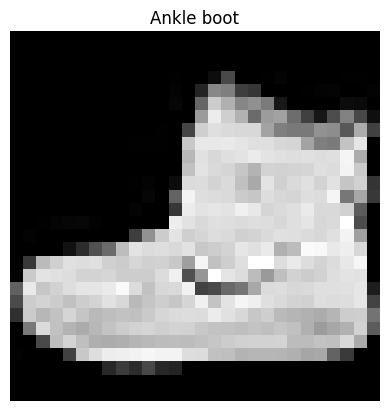

In [13]:
import matplotlib.pyplot as plt  # matplotlib 차트에 이미지 출력

# 데이터셋에서 첫번째 데이터 
image, label = train_dataset[0]

print(f'Tensor shape : {image.shape}')
print(f'Label : {label}')
print(f'Class name : {classes[label]}')

# 정규화 복원
# 현재범위가 -1~1 범위로 정규화한걸 다시 복원
# 필요없음(x) - 옵션
image = image * 0.5 + 0.5

# 이미지 출력
# [1, 28, 28] -> [28, 28]
image = image.squeeze()  # 1차원 제거

plt.imshow(image, cmap='gray')
plt.title(classes[label])
plt.axis('off')
plt.show()

### 10. 일반 로지스틱회귀 모델 클래스 선언
- CNN 사용안함, 이미지를 1차원 벡터로 펼쳐서 분류

In [65]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()

        # 입력크기 28 x 28 = 784
        # 출력크기 10개 클래스
        self.linear = nn.Linear(28 * 28, 10)

    def forward(self, x):
        # 이미지 펼치기(벡터로 변경)
        # [64, 1, 28, 28] -> [64, 784] 
        x = x.view(x.size(0), -1)

        # 계산
        x = self.linear(x)
        return x

### 11. 모델 객체 생성

In [15]:
model = LogisticRegression()
# 모델 객체 생성 시 모델객체도 GPU로 이동
model = model.to(device)

In [66]:
model

LogisticRegression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)

### 12. 손실함수 정의

In [16]:
# 다중클래스 분류에 사용하는 손실함수
loss_fn = nn.CrossEntropyLoss()

### 13. 최적화 알고리즘 정의

- 확률적 경사하강법 사용

In [17]:
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)

### 14. 모델 학습

In [67]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader: # 64번 반복
        # GPU로 이동
        images = images.to(device)
        labels = labels.to(device)

        # 기울기 초기화
        optimizer.zero_grad()

        # 예측값 계산 
        outputs = model(images) 

        # 손실계산        
        loss = loss_fn(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이터
        optimizer.step()
        
        # 현재 batch(64) 손실값을 누적
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f'[Epoch {epoch + 1}/{num_epochs}] Loss : {avg_loss:.4f}')


[Epoch 1/10] Loss : 0.4250
[Epoch 2/10] Loss : 0.4220
[Epoch 3/10] Loss : 0.4195
[Epoch 4/10] Loss : 0.4170
[Epoch 5/10] Loss : 0.4149
[Epoch 6/10] Loss : 0.4135
[Epoch 7/10] Loss : 0.4113
[Epoch 8/10] Loss : 0.4094
[Epoch 9/10] Loss : 0.4084
[Epoch 10/10] Loss : 0.4064


### 15. 모델 평가(테스트)

In [19]:
model.eval()

LogisticRegression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)

In [20]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # 예측
        outputs = model(images)

        # 가장 높은 확률 선택
        _, pred = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

accuracy = 100 * (correct / total)

print(f'\n테스트 정확도 : {accuracy:.2f}%')


테스트 정확도 : 83.31%


### 16. 마지막 예측 테스트

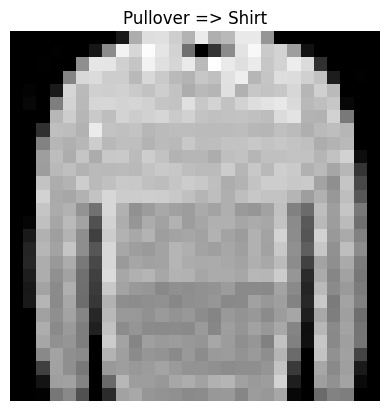

실제 답 : Pullover 예측결과 : Shirt


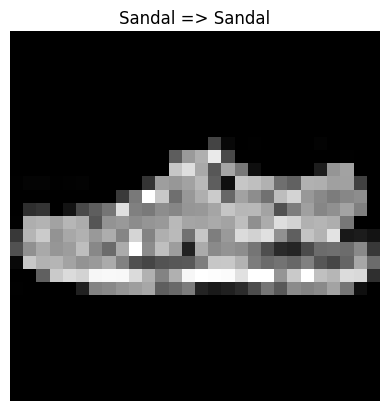

실제 답 : Sandal 예측결과 : Sandal


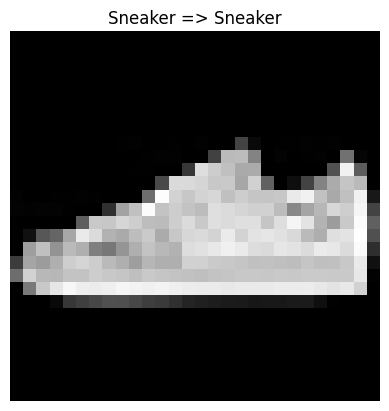

실제 답 : Sneaker 예측결과 : Sneaker


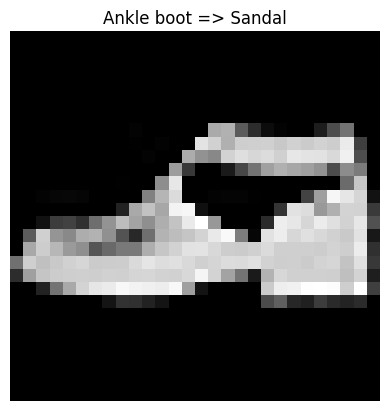

실제 답 : Ankle boot 예측결과 : Sandal


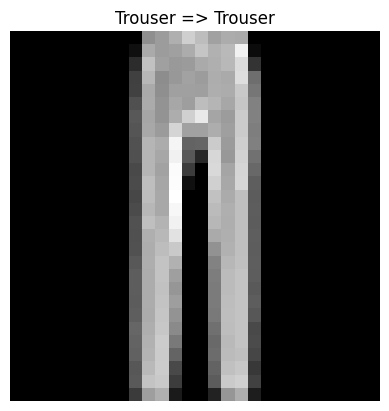

실제 답 : Trouser 예측결과 : Trouser


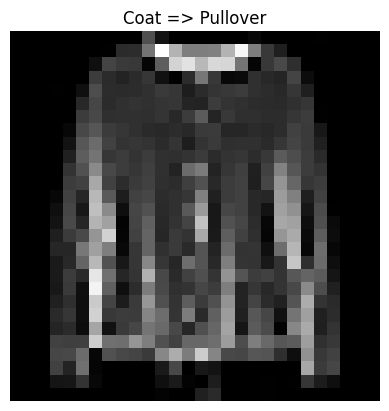

실제 답 : Coat 예측결과 : Pullover


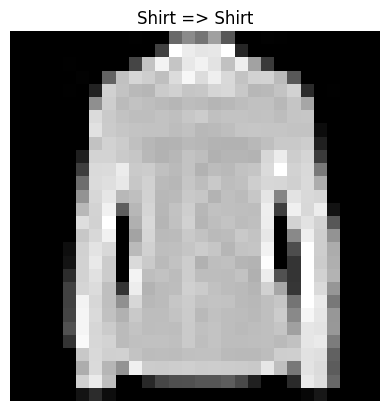

실제 답 : Shirt 예측결과 : Shirt


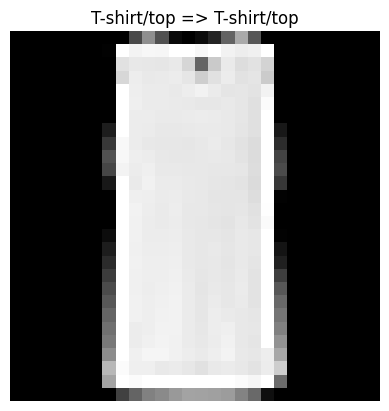

실제 답 : T-shirt/top 예측결과 : T-shirt/top


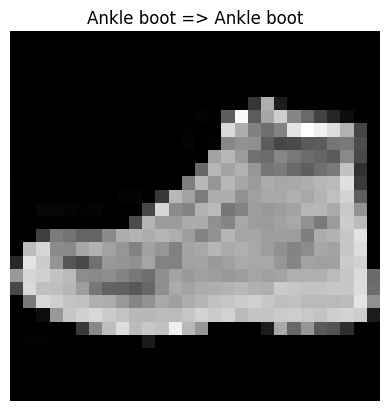

실제 답 : Ankle boot 예측결과 : Ankle boot


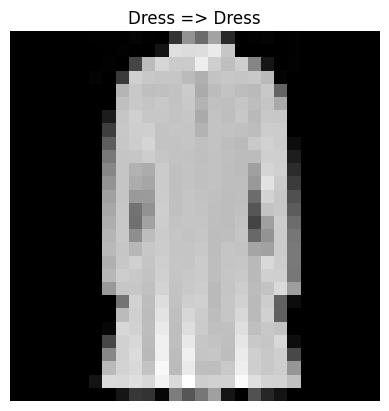

실제 답 : Dress 예측결과 : Dress


In [50]:
for i in range(20, 30):
    image, label = test_dataset[i]

    with torch.no_grad():
        # 차원 추가
        test_input = image.unsqueeze(0).to(device)

        # 출력
        output = model(test_input)

        predicted = torch.argmax(output, dim=1).item()

        plt.imshow(image.squeeze(), cmap='gray')
        # plt.figure(figsize=(28, 28))
        plt.title(f'{classes[label]} => {classes[predicted]}')
        plt.axis('off')
        plt.show()

    print(f'실제 답 : {classes[label]} 예측결과 : {classes[predicted]}')